# Accountability Patterns in AIAAIC

Comparing AIAAIC against the findings of *"From Incidents to Insights: Patterns of Responsibility following AI Harms"* (Hogan et al.), which analyzed 962 incidents from the AIID database. Do similar accounability patterns show up here?

Paper's main claims to check:
- developer = deployer (Big Tech self-operating) → less accounability
- organizational victims get more response than individual users
- anonymous actors (no identifiable deployer) → more legislative mobilization
- deepfakes drive the most societal mobilization

**Caveat:** AIAAIC and AIID code accounability differently. Response and consequence fields are ~75–80% missing in AIAAIC. So everything below is *documented* rates, not real-world rates.

### Setup

Load the cleaned data, match the websites analytical range (2015 onward, keeping undated), and convert the has_consequence / has_response fields to actual booleans.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

df = pd.read_csv('aiaaic_cleaned.csv')
df = df[(df['year'].isna()) | (df['year'] >= 2015)].reset_index(drop=True)
df['has_c'] = (df['has_consequence'].astype(str) == 'True')
df['has_r'] = (df['has_response'].astype(str) == 'True')

n = len(df)
n_c       = int(df['has_c'].sum())
n_r       = int(df['has_r'].sum())
n_both    = int((df['has_c'] & df['has_r']).sum())
n_neither = int(((~df['has_c']) & (~df['has_r'])).sum())

print(f'Total incidents (2015+): {n}')
print(f'  Consequence rate:  {n_c/n*100:5.1f}%  ({n_c})')
print(f'  Response rate:     {n_r/n*100:5.1f}%  ({n_r})')
print(f'  Both:              {n_both/n*100:5.1f}%  ({n_both})')
print(f'  Neither:           {n_neither/n*100:5.1f}%  ({n_neither})')

Total incidents (2015+): 2203
  Consequence rate:   25.1%  (553)
  Response rate:      21.1%  (464)
  Both:                6.2%  (136)
  Neither:            60.0%  (1322)


**Observation:** 
- Out of 2,203 incidents from 2015 on, only 25% have a documented consequence and 21% have a documented response.
- The dominant story is the 60% that have **neither** — three in five incidents fall into a black hole.
- Only 6.2% have both. Consequence and response are largely separate populations in this database.

### Developper—deployer relation

The paper says developer = deployer (Big Tech self-operating) generates fewer formal responses, and anonymous actors (no identifiable deployer) drive most legislative mobilization. Does AIAAIC show the same?

Set up a five-way classification: same entity, diferent entities, unknown developer, unknown deployer, both unknown.

In [2]:
# Multi-coded developer / deployer fields → sets of entities
def to_set(v):
    if pd.isna(v) or not str(v).strip():
        return set()
    return {t.strip() for t in str(v).split(';') if t.strip()}

df['dev_set'] = df['developer'].apply(to_set)
df['dep_set'] = df['deployer'].apply(to_set)

# `same_entity` requires any overlap between the two sets — a multi-coded row that
# lists the same company in both columns counts as same.
def dd_class(row):
    dev, dep = row['dev_set'], row['dep_set']
    if not dev and not dep:  return 'both_unknown'
    if not dev:              return 'dev_unknown'
    if not dep:              return 'dep_unknown'
    if dev & dep:            return 'same_entity'
    return 'different'

df['dd_class'] = df.apply(dd_class, axis=1)
print(df['dd_class'].value_counts())

dd_class
different       724
same_entity     724
dep_unknown     428
dev_unknown     196
both_unknown    131
Name: count, dtype: int64


In [3]:
def rate_table(d, group_col, count_col='aiaaic_id'):
    return (d.groupby(group_col).agg(
        n=(count_col, 'size'),
        consequence_rate=('has_c', lambda x: x.mean() * 100),
        response_rate=('has_r', lambda x: x.mean() * 100),
    ).round(1).sort_values('n', ascending=False))

dd_rates = rate_table(df, 'dd_class')
dd_rates['share_of_total'] = (dd_rates['n'] / len(df) * 100).round(1)
dd_rates

,n,consequence_rate,response_rate,share_of_total
dd_class,,,,
different,724,29.7,20.9,32.9
same_entity,724,25.1,27.5,32.9
dep_unknown,428,20.8,16.4,19.4
dev_unknown,196,20.9,17.3,8.9
both_unknown,131,19.8,7.6,5.9


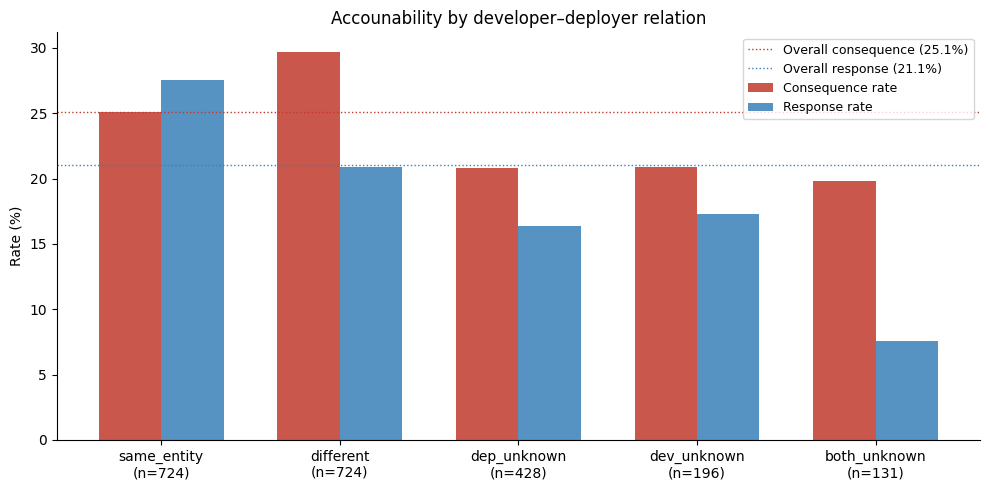

In [4]:
# paired bars per group, plus dotted overall baseline
OVERALL_C = df['has_c'].mean() * 100
OVERALL_R = df['has_r'].mean() * 100

ORDER = ['same_entity', 'different', 'dep_unknown', 'dev_unknown', 'both_unknown']
rates = dd_rates.reindex(ORDER)

fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(rates))
w = 0.35
ax.bar(x - w/2, rates['consequence_rate'], w, color='#c0392b', alpha=0.85, label='Consequence rate')
ax.bar(x + w/2, rates['response_rate'],    w, color='#3a80b8', alpha=0.85, label='Response rate')
ax.axhline(OVERALL_C, color='#c0392b', linestyle=':', linewidth=1, label=f'Overall consequence ({OVERALL_C:.1f}%)')
ax.axhline(OVERALL_R, color='#3a80b8', linestyle=':', linewidth=1, label=f'Overall response ({OVERALL_R:.1f}%)')
ax.set_xticks(x)
ax.set_xticklabels([f'{l}\n(n={n})' for l, n in zip(rates.index, rates['n'])], fontsize=10)
ax.set_ylabel('Rate (%)')
ax.set_title('Accounability by developer–deployer relation')
ax.spines[['top','right']].set_visible(False)
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.show()

**Observation:** 
- I expected `same_entity` to look worse but it actually has the **highest** response rate (27.5%). Opposite of the paper. Maybe AIAAIC volunteer curators just have more access to big tech press statements?
- `both_unknown` has the lowest response rate (7.6%) — this **does** match the paper. No actor to respond means no response gets documented.
- `different` (third-party deployer) has the highest consequence rate (29.7%). When there's a clear party to sue, lawsuits happen.

### No consequence AND no response

For each developer/deployer category, what share of incidents have neither a documented consequence nor a documented response? This is the "fell into a black hole" metric — incidents the database knows about but no accounability of any kind followed.

In [5]:
df['neither'] = (~df['has_c']) & (~df['has_r'])

ORDER = ['same_entity', 'different', 'dev_unknown', 'dep_unknown', 'both_unknown']
LABELS = {
    'same_entity':  'developer = deployer',
    'different':    'developer ≠ deployer',
    'dev_unknown':  'unknown developer',
    'dep_unknown':  'unknown deployer',
    'both_unknown': 'both unknown',
}

total_n       = len(df)
total_neither = int(df['neither'].sum())

rows = []
for cls in ORDER:
    sub = df[df['dd_class'] == cls]
    n_cat     = len(sub)
    n_neither = int(sub['neither'].sum())
    rows.append({
        'category':              LABELS[cls],
        'n_category':            n_cat,
        'n_neither':             n_neither,
        'pct_of_category':       round(n_neither / n_cat * 100, 1),
        'pct_of_total_neither':  round(n_neither / total_neither * 100, 1),
    })
rows.append({
    'category':             'TOTAL',
    'n_category':           total_n,
    'n_neither':            total_neither,
    'pct_of_category':      round(total_neither / total_n * 100, 1),
    'pct_of_total_neither': 100.0,
})

neither_table = pd.DataFrame(rows)
neither_table

,category,n_category,n_neither,pct_of_category,pct_of_total_neither
0,developer = deployer,724,402,55.5,30.4
1,developer ≠ deployer,724,411,56.8,31.1
2,unknown developer,196,130,66.3,9.8
3,unknown deployer,428,279,65.2,21.1
4,both unknown,131,100,76.3,7.6
5,TOTAL,2203,1322,60.0,100.0


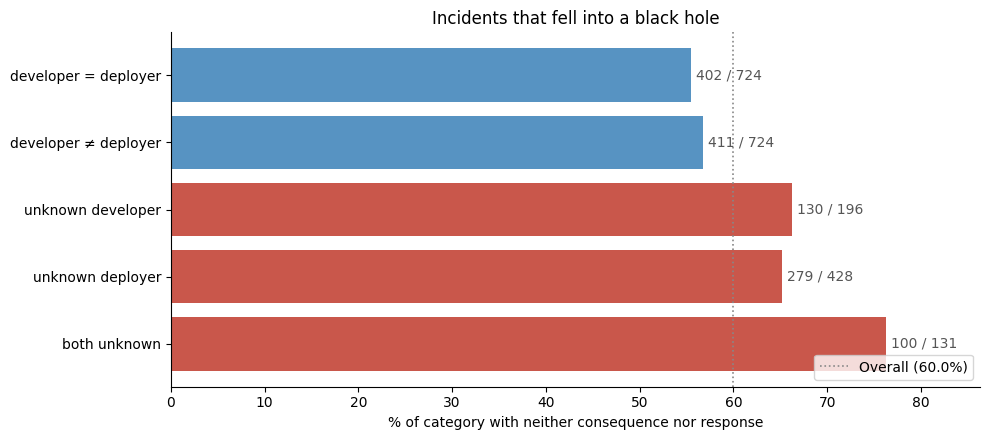

In [6]:
viz = neither_table[neither_table['category'] != 'TOTAL'].copy()
overall_pct = total_neither / total_n * 100

fig, ax = plt.subplots(figsize=(10, 4.5))
colors = ['#c0392b' if p > overall_pct else '#3a80b8' for p in viz['pct_of_category']]
bars = ax.barh(viz['category'], viz['pct_of_category'], color=colors, alpha=0.85)

for bar, nn, nc in zip(bars, viz['n_neither'], viz['n_category']):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{nn} / {nc}', va='center', fontsize=10, color='#555')

ax.axvline(overall_pct, color='#888', linestyle=':', linewidth=1.2,
           label=f'Overall ({overall_pct:.1f}%)')
ax.set_xlabel('% of category with neither consequence nor response')
ax.set_title('Incidents that fell into a black hole')
ax.set_xlim(0, max(viz['pct_of_category']) + 10)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

**Observation:** 
- Cleanly monotonic with attribution loss. 55–57% neither when both actors are known, 65% when one is missing, 76% when both are missing. Three quaters of "both unknown" incidents produced nothing.
- "both unknown" is the only category that visibly differs from the 60% baseline. The two known-actor categories sit within 1.3 points of each other — same vs diferent matters less than known vs unknown.
- The paper's structural finding does replicate here. When no one can be named, no accounability of any kind happens. This is the database-robust signal worth visualizing on the website.

### Legislative mobilization

The paper claims anonymous incidents trigger more legislative mobilization — legislative complaints, legislator letters, legislative proposals. Test against AIAAIC by flagging incidents with these tags.

Caveat: legislative tags are rare (~1.2% overall) so sub-group rates are noisy.

In [7]:
LEGIS_TAGS = {'Legislative complaint', 'Legislator letter', 'Legislative proposal'}

def has_legis(v):
    if pd.isna(v) or not str(v).strip(): return False
    return bool({t.strip() for t in str(v).split(';')} & LEGIS_TAGS)

df['has_legis'] = df['consequence'].apply(has_legis)

df.groupby('dd_class').agg(
    n=('aiaaic_id', 'size'),
    legis_rate=('has_legis', lambda x: x.mean() * 100),
    legis_n=('has_legis', 'sum'),
).round(2).sort_values('legis_rate', ascending=False)

,n,legis_rate,legis_n
dd_class,,,
same_entity,724,1.80,13
different,724,1.10,8
both_unknown,131,0.76,1
dep_unknown,428,0.70,3
dev_unknown,196,0.00,0


**Observation:** 
- In raw rate, `same_entity` actually has the highest legislative rate (1.8%) and `dev_unknown` has zero. Opposite of paper.
- But absolute counts are tiny — 13 legislative incidents in same_entity, 0 in dev_unknown. Probaby just noise.
- AIAAIC's legislative tags are heavy on lawsuits naming big tech defendants. AIID may catch more diffuse mobilization signals (op-eds, advocay campaigns, etc.) we don't have here.
- I'd treat this as inconclusive rather than a real disagreement with the paper.

### Big Tech accountability

Are major AI companies less accountable when operating their own products? Define a big tech list, split by whether the developer is in it and whether dev = deployer.

In [8]:
BIG_TECH = {'OpenAI', 'Google', 'Meta', 'Meta Platforms', 'Facebook', 'Microsoft', 'Amazon',
            'Apple', 'Tesla', 'xAI', 'Anthropic', 'TikTok', 'Nvidia', 'ByteDance'}

def bt_class(row):
    bt_in_dev = bool(row['dev_set'] & BIG_TECH)
    same = row['dd_class'] == 'same_entity'
    different = row['dd_class'] == 'different'
    if bt_in_dev and same:      return 'BigTech self-op'
    if bt_in_dev and different: return 'BigTech dev, other dep'
    if (not bt_in_dev) and same:      return 'Other self-op'
    if (not bt_in_dev) and different: return 'Other dev, other dep'
    return 'unknown / mixed'

df['bt_class'] = df.apply(bt_class, axis=1)
rate_table(df, 'bt_class')

,n,consequence_rate,response_rate
bt_class,,,
unknown / mixed,755,20.7,15.1
"Other dev, other dep",480,27.5,23.3
Other self-op,421,25.7,27.6
BigTech self-op,303,24.4,27.4
"BigTech dev, other dep",244,34.0,16.0


In [9]:
# Per-company breakdown for the top developers
rows = []
for company in sorted(BIG_TECH):
    sub = df[df['dev_set'].apply(lambda s: company in s)]
    if len(sub) < 20:
        continue
    same_share = (sub['dd_class'] == 'same_entity').mean() * 100
    rows.append({
        'company': company,
        'n': len(sub),
        'self_op_share': round(same_share, 1),
        'cons_rate': round(sub['has_c'].mean() * 100, 1),
        'resp_rate': round(sub['has_r'].mean() * 100, 1),
    })
pd.DataFrame(rows).sort_values('n', ascending=False)

,company,n,self_op_share,cons_rate,resp_rate
7,OpenAI,233,30.5,18.9,9.9
4,Google,127,50.4,23.6,30.7
8,Tesla,73,5.5,71.2,16.4
0,Amazon,72,65.3,29.2,15.3
6,Microsoft,68,48.5,22.1,17.6
3,Facebook,66,75.8,24.2,47.0
9,xAI,48,29.2,22.9,20.8
5,Meta Platforms,38,26.3,18.4,13.2
1,Anthropic,23,34.8,17.4,21.7
2,Apple,23,65.2,21.7,17.4


**Observation:** 
- AIAAIC does **not** show a big tech accounability gap like AIID does. Big tech self-operating sits near overall averages on both consequence and response, not noticably lower.
- Per-company variation is wider than the between-category variation. Tesla generates many incidents but with a very diferent profile (litigation-heavy from physical-injury crashes) compared to OpenAI (text-only LLM harms, mostly Reg investigation + Litigation).
- One possibility: AIAAIC seems to code annoucements of consequences ("X has been sued") more liberally than AIID. That inflates the big tech consequence rate without actual enforcement.

### Victim type

The paper claims organizational victims (companies, public institutions) get more accountability than individual users. AIAAIC's schema separates harm by who is harmed: individual vs societal vs environmental.

In [10]:
def victim(row):
    has_i = pd.notna(row['harm_individual']) and str(row['harm_individual']).strip() != ''
    has_s = pd.notna(row['harm_societal'])   and str(row['harm_societal']).strip()   != ''
    if has_i and has_s: return 'both individual & societal'
    if has_i:           return 'individual only'
    if has_s:           return 'societal only'
    return 'no harm coded'

df['victim'] = df.apply(victim, axis=1)
rate_table(df, 'victim').sort_values('consequence_rate', ascending=False)

,n,consequence_rate,response_rate
victim,,,
both individual & societal,84,35.7,15.5
individual only,710,32.7,19.3
societal only,784,24.6,23.2
no harm coded,625,15.7,21.1


**Observation:** 
- In AIAAIC, individual victims actually get **more** documented consequence (32.7%) than societal victims (24.6%). Opposite of paper.
- This probaby reflects AIAAIC's coding bias. Litigation dominates the consequence taxonomy and most lawsuits are individual-injury cases (privacy, IP, personal harm).
- "Both" category is highest (35.7%) but tiny (n=84). Incidents that harm both individuals and society are by definition the most visible ones — selection effect.
- "no harm coded" has the lowest consequence rate (15.7%). Probaby selection effect again: incidents that didn't get fully coded probably lack the documentation that produces consequence tags.

### Deepfake patterns

The paper claims deepfakes drive societal mobilization, precisely because no direct deployer exists. Compare deepfake-flagged incidents against everything else.

In [11]:
df['is_df'] = df['is_deepfake'].astype(str) == 'True'

comparison = pd.DataFrame({
    'group':       ['Deepfake', 'Other'],
    'n':           [df['is_df'].sum(), (~df['is_df']).sum()],
    'cons_rate':   [df[df['is_df']]['has_c'].mean()*100,  df[~df['is_df']]['has_c'].mean()*100],
    'resp_rate':   [df[df['is_df']]['has_r'].mean()*100,  df[~df['is_df']]['has_r'].mean()*100],
    'legis_rate':  [df[df['is_df']]['has_legis'].mean()*100, df[~df['is_df']]['has_legis'].mean()*100],
    'unknown_dev_share': [
        (df[df['is_df']]['dev_set'].apply(len) == 0).mean() * 100,
        (df[~df['is_df']]['dev_set'].apply(len) == 0).mean() * 100,
    ],
}).round(1)
comparison

,group,n,cons_rate,resp_rate,legis_rate,unknown_dev_share
0,Deepfake,203,19.7,9.4,0.5,63.1
1,Other,2000,25.6,22.2,1.2,10.0


**Observation:** 
- Deepfakes have **lower** response rate (9.4% vs 22.2%). Partly matches the paper's powerlessness finding — no clear deployer means no response gets documented.
- But AIAAIC does **not** show deepfakes triggering more legislative mobilization (0.5% vs 1.2%). Contradicts paper. Maybe AIAAIC undercounts legislative reactions (focuses on incident-specific consequences not broader policy reactions). Or the time period covered here doesn't yet show the legislative effect AIID documented.
- Much higher share of deepfake incidents have unknown developers — confirms the structural observation that deepfakes lack attribution.

### Summary: AIAAIC vs paper findings

| Paper claim (from AIID) | AIAAIC observation | Match? |
|---|---|---|
| dev=deployer → fewer responses | dev=deployer has the *highest* response rate (27.5%) | ❌ opposite |
| both unknown → fewer responses | both unknown has the lowest response rate (7.6%) | ✅ matches |
| Organizational victims get more | Individual victims get more consequence (32.7% > 24.6%) | ❌ opposite |
| Anonymous → more legislative mobilization | Sample too small; slightly opposite | ⚠️ inconclusive |
| Deepfakes → societal mobilization | Lower response, lower legislative | ❌ opposite |
| Big Tech accountability gap | Near baseline | ❌ no clear gap |

**The finding that survives the database difference:**

When no actor is identifiable, no accounability of any kind gets recorded. The "both unknown" 7.6% response rate and 76% "neither" rate are the database-robust signals. Everything else mostly reflects encoding differences between AIID and AIAAIC.

For the visualization: don't import the paper's findings wholesale. Anchor on what AIAAIC actually shows — the attribution-loss → accounability-loss pattern, which is the one structural finding both databases agree on.